# Phase 4: Conduct image classification using the convolutional neural network approach

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import copy

In [24]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'

# Define Data Augmentation and Normalization
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),  # Flip images horizontally
    transforms.RandomRotation(20),  # Rotate images
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Define class names
class_names = train_dataset.classes
num_classes = len(class_names)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv Layer 1
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduce size by half
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Conv Layer 2
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # Conv Layer 3
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # Conv Layer 4
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),  # Fully connected layer
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),  # Dropout for regularization
            
            nn.Linear(512, num_classes)  # Output layer
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model, loss function, optimizer, and scheduler
model = CNNModel(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Save PyTorch model
torch.save(model.state_dict(), "Phase4_model.pth")

# Load PyTorch model
model.load_state_dict(torch.load("Phase4_model.pth", weights_only=True))
model.eval()

# Early Stopping
patience = 10
best_loss = float('inf')
epochs_without_improvement = 0
best_model_wts = copy.deepcopy(model.state_dict())

# Lists to track loss and accuracy
train_losses, train_accuracies = [], []
valid_losses, valid_accuracies = [], []

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # Validation Step
    model.eval()
    valid_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    valid_accuracy = correct / total
    valid_losses.append(valid_loss / len(test_loader))
    valid_accuracies.append(valid_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Valid Loss: {valid_losses[-1]:.4f}, Valid Acc: {valid_accuracies[-1]:.4f}")

    # Check for Early Stopping
    if valid_losses[-1] < best_loss:
        best_loss = valid_losses[-1]
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered!")
        break

    scheduler.step(valid_loss)


Epoch [1/50], Train Loss: 2.6130, Train Acc: 0.1713, Valid Loss: 2.3646, Valid Acc: 0.2427
Epoch [2/50], Train Loss: 2.3167, Train Acc: 0.2535, Valid Loss: 2.2123, Valid Acc: 0.3113
Epoch [3/50], Train Loss: 2.1575, Train Acc: 0.3132, Valid Loss: 1.9857, Valid Acc: 0.3620
Epoch [4/50], Train Loss: 2.0134, Train Acc: 0.3613, Valid Loss: 1.8982, Valid Acc: 0.4047
Epoch [5/50], Train Loss: 1.9139, Train Acc: 0.3888, Valid Loss: 2.0064, Valid Acc: 0.3707
Epoch [6/50], Train Loss: 1.8387, Train Acc: 0.4102, Valid Loss: 1.8418, Valid Acc: 0.4107
Epoch [7/50], Train Loss: 2.1195, Train Acc: 0.3212, Valid Loss: 2.0162, Valid Acc: 0.3787
Epoch [8/50], Train Loss: 2.0189, Train Acc: 0.3658, Valid Loss: 1.8865, Valid Acc: 0.4033
Epoch [9/50], Train Loss: 1.8683, Train Acc: 0.3988, Valid Loss: 1.8272, Valid Acc: 0.4347
Epoch [10/50], Train Loss: 1.7759, Train Acc: 0.4307, Valid Loss: 1.7726, Valid Acc: 0.4367
Epoch [11/50], Train Loss: 1.7122, Train Acc: 0.4515, Valid Loss: 1.7092, Valid Acc: 0.44

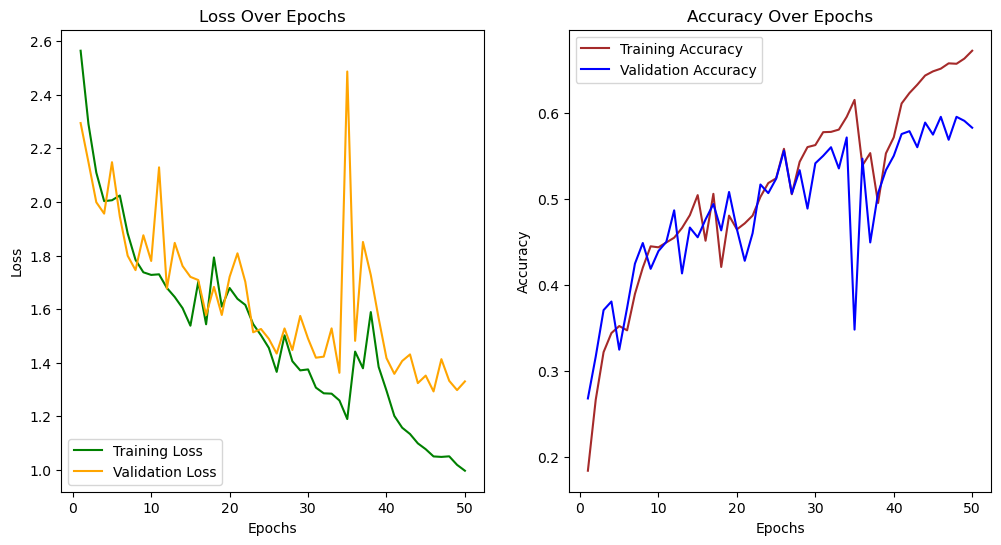

In [21]:
# Plot training curves
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='green')
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='Validation Loss', color='orange')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy', color='brown')
plt.plot(range(1, len(valid_accuracies) + 1), valid_accuracies, label='Validation Accuracy', color='blue')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Test Accuracy: 0.5900
              precision    recall  f1-score   support

   n01644900       0.49      0.47      0.48       100
   n01944390       0.51      0.44      0.47       100
   n01945685       0.51      0.36      0.42       100
   n02129165       0.54      0.68      0.60       100
   n02206856       0.56      0.70      0.62       100
   n02233338       0.57      0.47      0.52       100
   n02437312       0.57      0.62      0.59       100
   n02666196       0.61      0.53      0.57       100
   n02669723       0.71      0.60      0.65       100
   n02699494       0.64      0.63      0.63       100
   n02791270       0.43      0.51      0.47       100
   n02948072       0.56      0.63      0.59       100
   n03026506       0.62      0.69      0.65       100
   n03042490       0.69      0.70      0.69       100
   n03100240       0.88      0.82      0.85       100

    accuracy                           0.59      1500
   macro avg       0.59      0.59      0.59      1500
weig

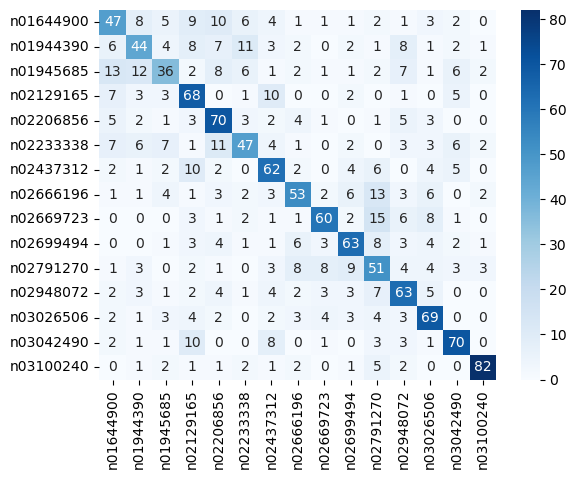

In [19]:
# Load the best model weights
model.load_state_dict(best_model_wts)

# Evaluate Model Performance
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.show()
